<img src="Logo_UNSAM.png" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº5
#### Santiago Boente

En este trabajo practico tuvimos como finalidad estimar la densidad espectral de potencia de múltiples señales (electrocardiogramas, pletismografías y audios) usando métodos vistos en clase. En este caso usaremos el método de Welch. 

Habiendo hecho esto, estimaremos el ancho de banda de cada potencia.

Para usar el método de Welch hay que elegir un nperseg (cantidad de muestras que tiene cada segmento) acorde a la señal analizada. 

Un nperseg alto implica: 

- mejor resolución en frecuencia

- menos segmentos para promediar
  
- una PSD más detallada pero más variable. 

Un nperseg bajo implica: 

- peor resolución en frecuencia
  
- más segmentos para promediar
  
- PSD más suave pero menos detallada


Para estimar el ancho de banda buscaremos el punto donde la frecuencia se acumula al 95% de potencia. En el caso de un pasabanda serán 2 puntos. 

En primer lugar, analizaremos un ECG con ruido:

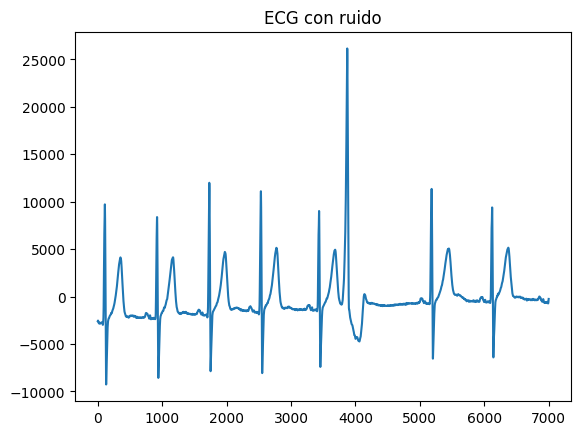

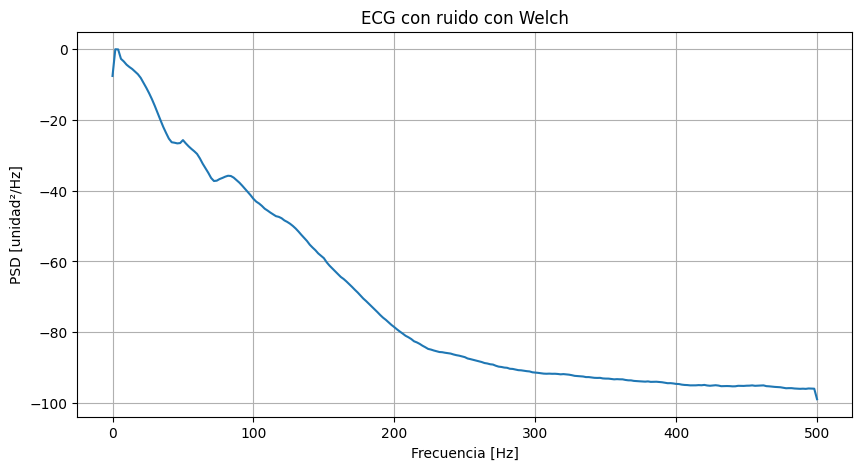

In [70]:
import numpy as np
from scipy import signal as sig

import matplotlib.pyplot as plt
   
import scipy.io as sio
from scipy.io.wavfile import write


#%%

##################
# Lectura de ECG #
##################

fs_ecg = 1000 # Hz

##################
## ECG con ruido
##################

# para listar las variables que hay en el archivo
sio.whosmat('ECG_TP4.mat')
mat_struct = sio.loadmat('ECG_TP4.mat')

ecg_one_lead = mat_struct['ecg_lead']
N = len(ecg_one_lead)

hb_1 = mat_struct['heartbeat_pattern1']
hb_2 = mat_struct['heartbeat_pattern2']

plt.figure()
plt.plot(ecg_one_lead[5000:12000])
plt.title('ECG con ruido')

#plt.figure()
#plt.plot(hb_1)

#plt.figure()
#plt.plot(hb_2)

x = ecg_one_lead[:, 0]
x = x - np.mean(x)

f, Pxx = sig.welch(x, fs=fs_ecg, nperseg = 500)

Pxx_max = np.max(Pxx)

Pxx_norm = Pxx/Pxx_max
Pxx_db = 10*np.log10(np.abs(Pxx_norm))

plt.figure(figsize=(10, 5))
plt.plot(f, Pxx_db)
plt.grid(True) 
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [unidad²/Hz]")
plt.title('ECG con ruido con Welch')
plt.show()

Se trata de un filtro pasabajos, por ende el ancho de banda será:

In [71]:
pot_total = np.sum(Pxx)
pot_acumulada = 0

for i in range(len(Pxx)):
    pot_acumulada = pot_acumulada + Pxx[i]

    if pot_acumulada >= 0.95 * pot_total:
        BW_95 = f[i]
        break

print("Ancho de banda al 95%:", BW_95, "Hz")

Ancho_ECG_ruido = BW_95

Ancho de banda al 95%: 24.0 Hz


Ahora analizaremos un ECG sin ruido:

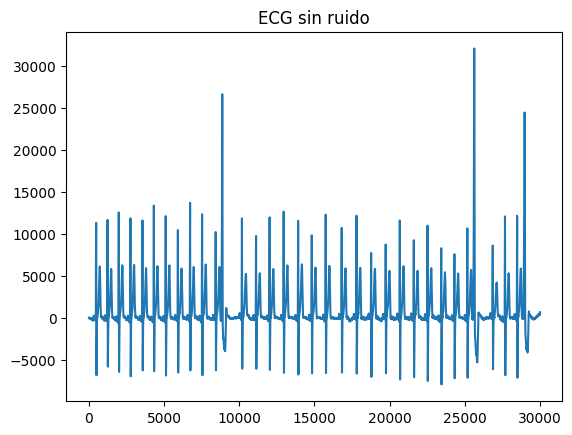

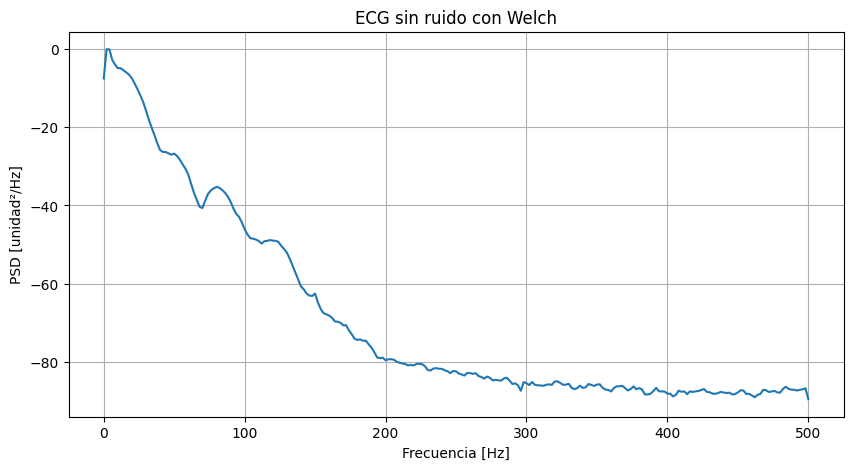

In [72]:
##################
## ECG sin ruido
##################

ecg_one_lead_sin_ruido = np.load('ecg_sin_ruido.npy')

plt.figure()
plt.plot(ecg_one_lead_sin_ruido)
plt.title('ECG sin ruido')

x_sin = ecg_one_lead_sin_ruido - np.mean(ecg_one_lead_sin_ruido) 

f_sin, Pxx_sin = sig.welch(x_sin, fs=fs_ecg, nperseg = 500)

Pxx_max = np.max(Pxx_sin)

Pxx_norm = Pxx_sin/Pxx_max

Pxx_db = 10*np.log10(np.abs(Pxx_norm))

plt.figure(figsize=(10, 5))
plt.plot(f_sin, Pxx_db)
plt.grid(True) 
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [unidad²/Hz]")
plt.title('ECG sin ruido con Welch')
plt.show()

pot_total = np.sum(Pxx_sin)
pot_acumulada = 0

Se trata de un filtro pasabajos, por ende el ancho de banda será:

In [73]:
for i in range(len(Pxx_sin)):
    pot_acumulada = pot_acumulada + Pxx_sin[i]

    if pot_acumulada >= 0.95 * pot_total:
        BW_95 = f_sin[i]
        break

print("Ancho de banda al 95%:", BW_95, "Hz")

Ancho_ECG_sin_ruido = BW_95

Ancho de banda al 95%: 24.0 Hz


Ahora analizaremos un PPG con ruido:

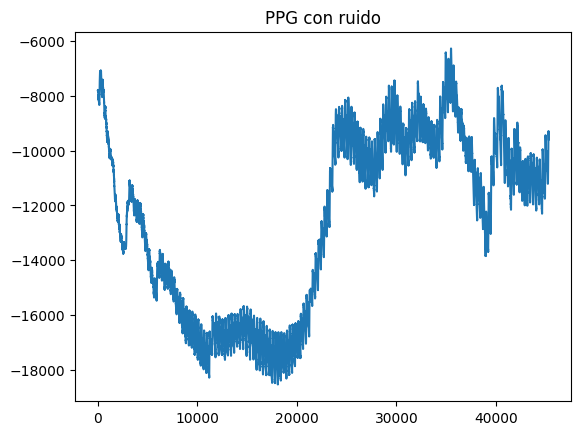

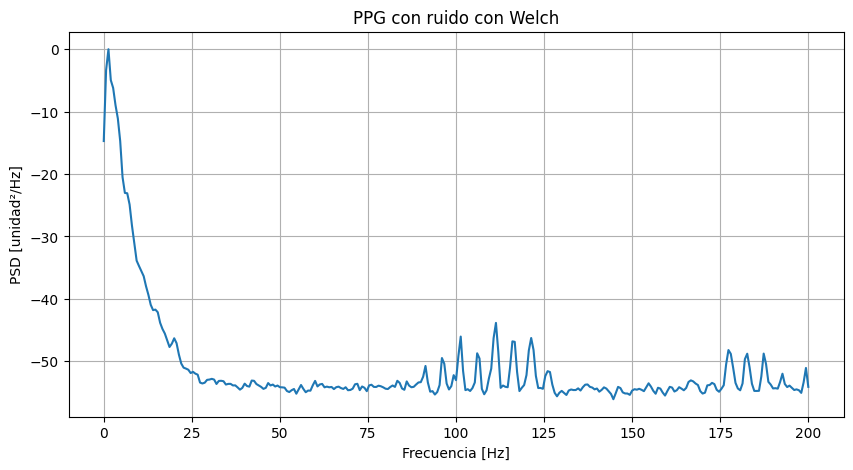

In [74]:
####################################
# Lectura de pletismografía (PPG)  #
####################################

fs_ppg = 400 # Hz

##################
## PPG con ruido
##################

# # Cargar el archivo CSV como un array de NumPy
ppg = np.genfromtxt('PPG.csv', delimiter=',', skip_header=1)  # Omitir la cabecera si existe

plt.figure()
plt.plot(ppg)
plt.title('PPG con ruido')
plt.show()

x_ppg = ppg - np.mean(ppg)

f_ppg, Pxx = sig.welch(x_ppg, fs=fs_ppg, nperseg = 600)

Pxx_max = np.max(Pxx)
Pxx_norm = Pxx/Pxx_max
Pxx_db = 10*np.log10(np.abs(Pxx_norm))

plt.figure(figsize=(10, 5))
plt.plot(f_ppg, Pxx_db)
plt.grid(True) 
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [unidad²/Hz]")
plt.title('PPG con ruido con Welch')
plt.show()

Se trata de un filtro pasabajos, por ende el ancho de banda será:

In [75]:
pot_total = np.sum(Pxx)
pot_acumulada = 0

for i in range(len(Pxx)):
    pot_acumulada = pot_acumulada + Pxx[i]

    if pot_acumulada >= 0.95 * pot_total:
        BW_95 = f_ppg[i]
        break

print("Ancho de banda al 95%:", BW_95, "Hz")

Ancho_PPG_ruido = BW_95

Ancho de banda al 95%: 4.0 Hz


Ahora analizaremos un PPG sin ruido:

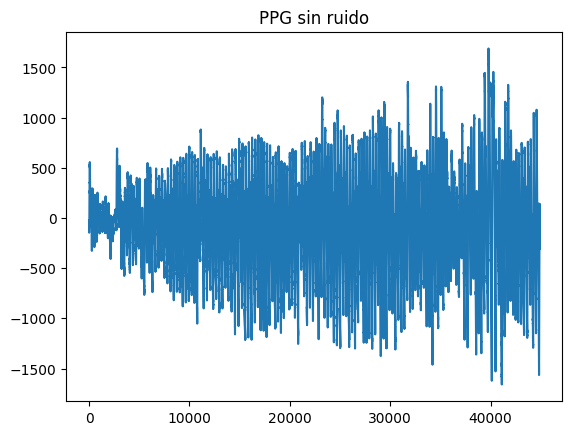

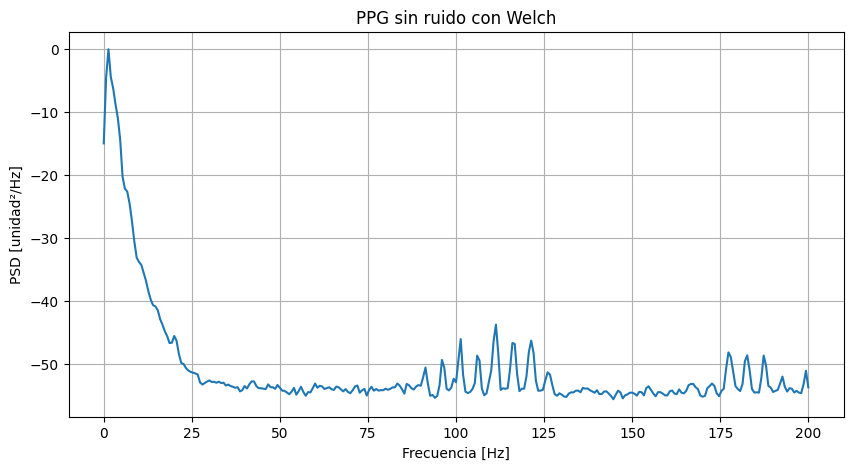

In [76]:
##################
## PPG sin ruido
##################

ppg = np.load('ppg_sin_ruido.npy')

plt.figure()
plt.plot(ppg)
plt.title('PPG sin ruido')
plt.show()

x_ppg = ppg - np.mean(ppg)

f_ppg, Pxx = sig.welch(x_ppg, fs=fs_ppg, nperseg = 600)

Pxx_max = np.max(Pxx)

Pxx_norm = Pxx/Pxx_max
Pxx_db = 10*np.log10(np.abs(Pxx_norm))

plt.figure(figsize=(10, 5))
plt.plot(f_ppg, Pxx_db)
plt.grid(True) 
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [unidad²/Hz]")
plt.title('PPG sin ruido con Welch')
plt.show()

Se trata de un filtro pasabajos, por ende el ancho de banda será:

In [77]:
pot_total = np.sum(Pxx)
pot_acumulada = 0

for i in range(len(Pxx)):
    pot_acumulada = pot_acumulada + Pxx[i]

    if pot_acumulada >= 0.95 * pot_total:
        BW_95 = f_ppg[i]
        break

print("Ancho de banda al 95%:", BW_95, "Hz")

Ancho_PPG_sin_ruido = BW_95

Ancho de banda al 95%: 4.0 Hz


Ahora analizaremos múltiples lecturas de audio, empezando por la cucaracha:

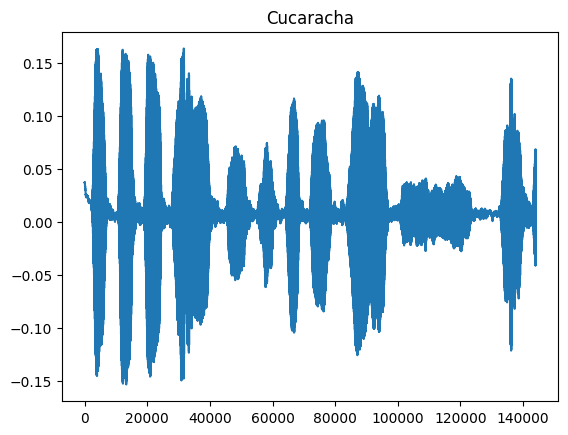

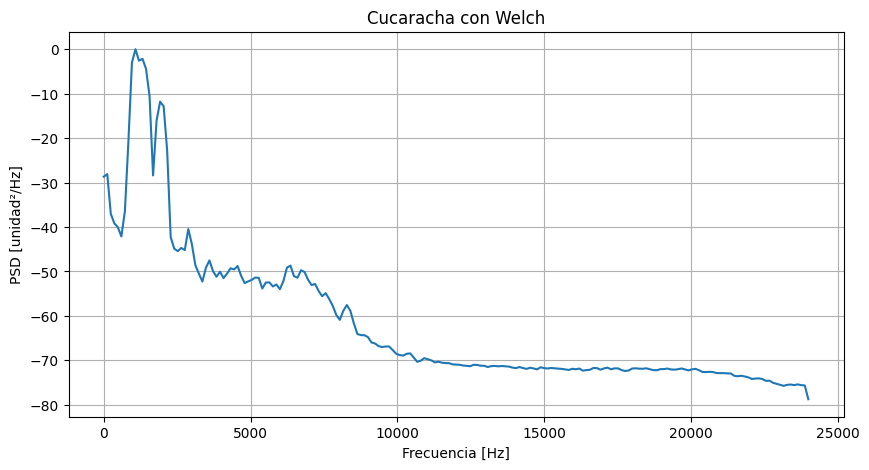

In [78]:
####################
# Lectura de audio #
####################

# Cargar el archivo CSV como un array de NumPy
fs_audio, wav_data = sio.wavfile.read('la cucaracha.wav')

plt.figure()
plt.plot(wav_data)
plt.title("Cucaracha")

xa = wav_data
xa = wav_data - np.mean(wav_data)

f_a, Pxx_a = sig.welch(xa, fs=fs_audio, nperseg = 400)

Pxx_max = np.max(Pxx_a)

Pxx_norm = Pxx_a/Pxx_max
Pxx_db = 10*np.log10(np.abs(Pxx_norm))

plt.figure(figsize=(10, 5))
plt.plot(f_a, Pxx_db)
plt.grid(True) 
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [unidad²/Hz]")
plt.title("Cucaracha con Welch")
plt.show()

Se trata de un filtro pasabanda entonces para calcular el ancho de banda, para calcularlo busco las 2 frecuencias donde está acumulado el 95% de la potencia total.:

In [79]:
pot_total = np.sum(Pxx_a)

pot_acumulada = 0

f1 = None
f2 = None

for i in range(len(Pxx_a)):
    pot_acumulada = pot_acumulada + Pxx_a[i]

    porcentaje = pot_acumulada / pot_total

    if f1 is None and porcentaje >= 0.025:
        f1 = f_a[i]

    if f2 is None and porcentaje >= 0.975:
        f2 = f_a[i]
        break

BW_95 = f2 - f1

print("Ancho de banda al 2.5%:", f1, "Hz")
print("Ancho de banda al 97.5%:", f2, "Hz")
print("Ancho de banda al 95%:", BW_95, "Hz")

Ancho_cucaracha = BW_95

Ancho de banda al 2.5%: 960.0 Hz
Ancho de banda al 97.5%: 1920.0 Hz
Ancho de banda al 95%: 960.0 Hz


Ahora analizaremos una prueba de PSD:

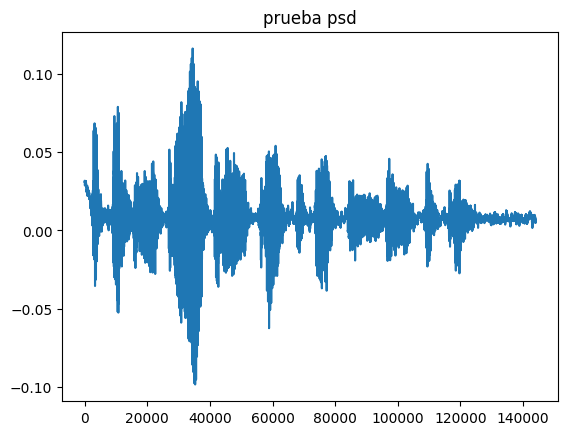

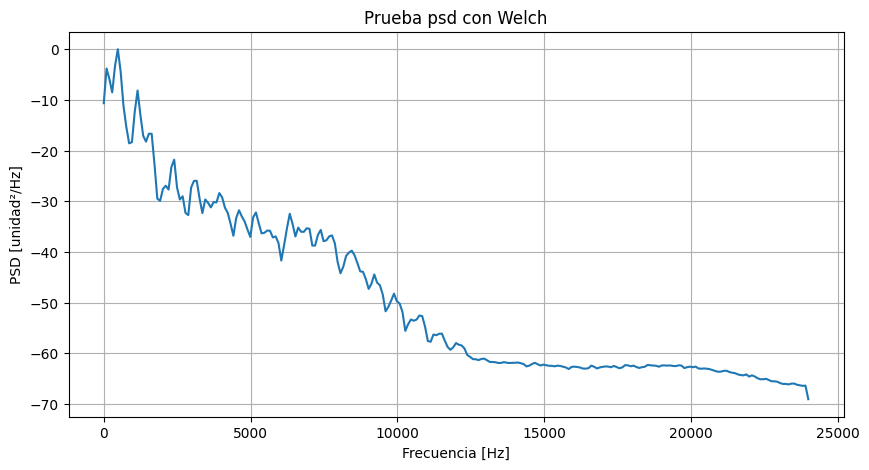

In [80]:
fs_audio, wav_data = sio.wavfile.read('prueba psd.wav')

plt.figure()
plt.plot(wav_data)
plt.title("prueba psd")

xa = wav_data
xa = wav_data - np.mean(wav_data)

f_a, Pxx_a = sig.welch(xa, fs=fs_audio, nperseg = 500)

Pxx_max = np.max(Pxx_a)

Pxx_norm = Pxx_a/Pxx_max
Pxx_db = 10*np.log10(np.abs(Pxx_norm))

plt.figure(figsize=(10, 5))
plt.plot(f_a, Pxx_db)
plt.grid(True) 
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [unidad²/Hz]")
plt.title("Prueba psd con Welch")
plt.show()

Se trata de un filtro pasabajos, por ende el ancho de banda será:

In [81]:
pot_total = np.sum(Pxx_a)
pot_acumulada = 0

for i in range(len(Pxx_a)):
    pot_acumulada = pot_acumulada + Pxx_a[i]

    if pot_acumulada >= 0.95 * pot_total:
        BW_95 = f_a[i]
        break

print("Ancho de banda al 95%:", BW_95, "Hz")


Ancho_prueba = BW_95

Ancho de banda al 95%: 1248.0 Hz


Finalmente analizaremos una señal de ruido de silbido:

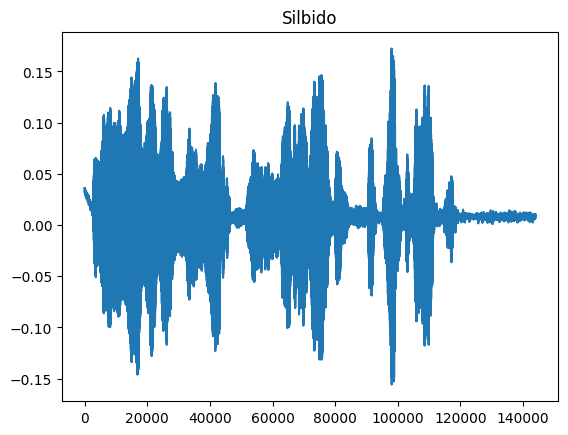

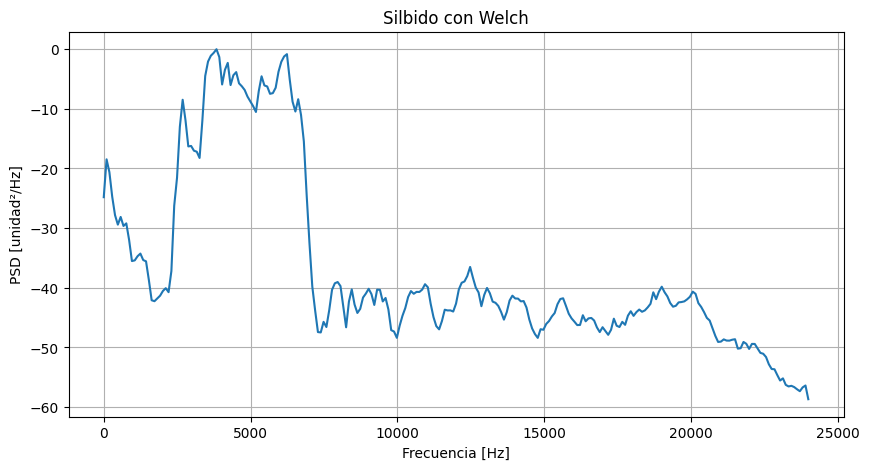

In [82]:
fs_audio, wav_data = sio.wavfile.read('silbido.wav')


plt.figure()
plt.plot(wav_data)
plt.title("Silbido")

xa = wav_data
xa = wav_data - np.mean(wav_data)

f_a, Pxx_a = sig.welch(xa, fs=fs_audio, nperseg = 500)

Pxx_max = np.max(Pxx_a)

Pxx_norm = Pxx_a/Pxx_max
Pxx_db = 10*np.log10(np.abs(Pxx_norm))

plt.figure(figsize=(10, 5))
plt.plot(f_a, Pxx_db)
plt.grid(True) 
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [unidad²/Hz]")
plt.title("Silbido con Welch")
plt.show()

Se trata de un filtro pasabanda entonces para calcular el ancho de banda:

In [83]:
pot_total = np.sum(Pxx_a)

pot_acumulada = 0

f1 = None
f2 = None

for i in range(len(Pxx_a)):
    pot_acumulada = pot_acumulada + Pxx_a[i]

    porcentaje = pot_acumulada / pot_total

    if f1 is None and porcentaje >= 0.025:
        f1 = f_a[i]

    if f2 is None and porcentaje >= 0.975:
        f2 = f_a[i]
        break

BW_95 = f2 - f1

print("Ancho de banda al 2.5%:", f1, "Hz")
print("Ancho de banda al 97.5%:", f2, "Hz")
print("Ancho de banda al 95%:", BW_95, "Hz")

Ancho_silbido = BW_95

Ancho de banda al 2.5%: 2976.0 Hz
Ancho de banda al 97.5%: 6528.0 Hz
Ancho de banda al 95%: 3552.0 Hz


In [84]:
print("--------------------------------------")
print("Señal                 BW [Hz]")
print("--------------------------------------")

print(f"ECG con ruido      {Ancho_ECG_ruido:10.2f}")
print(f"ECG sin ruido      {Ancho_ECG_sin_ruido:10.2f}")
print(f"PPG con ruido      {Ancho_PPG_ruido:10.2f}")
print(f"PPG sin ruido      {Ancho_PPG_sin_ruido:10.2f}")
print(f"La cucaracha       {Ancho_cucaracha:10.2f}")
print(f"Prueba PSD         {Ancho_prueba:10.2f}")
print(f"Silbido            {Ancho_silbido:10.2f}")

print("--------------------------------------")

--------------------------------------
Señal                 BW [Hz]
--------------------------------------
ECG con ruido           24.00
ECG sin ruido           24.00
PPG con ruido            4.00
PPG sin ruido            4.00
La cucaracha           960.00
Prueba PSD            1248.00
Silbido               3552.00
--------------------------------------


#### Conclusión:

En este trabajo se estimó la densidad espectral de potencia de señales ECG, PPG y audio mediante el método de Welch. Este análisis permitió observar cómo se distribuye la potencia de cada señal en frecuencia y comparar el efecto del ruido sobre estas mismas. En ECG y PPG se observó que la mayor parte de la energía se concentra en bajas frecuencias, mientras que en las señales de audio el contenido espectral se distribuye en una banda más amplia. Además, se pudo verificar que la elección de los parámetros de Welch influye en el compromiso entre resolución frecuencial y suavizado de la estimación. Finalmente, la estimación del ancho de banda permitió caracterizar de forma simple el rango de frecuencias más relevante de cada señal.